Nama: Ajie Armansyah Sunaryo  
NIM: 24/545286/PA/23170
# <center> Implementation for image enhancement

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 1. Dark Image menjadi Terang (Pencerahan)
Menggunakan Power-Law (Gamma) Transformation dengan rumus $s = c r^\gamma$. Dengan memasukkan nilai $\gamma < 1$ (misalnya 0.5), kurva matematis akan meregangkan piksel-piksel yang bernilai rendah (gelap) menjadi lebih tinggi (terang) secara eksponensial, tanpa membuat area yang sudah putih menjadi over-exposed.

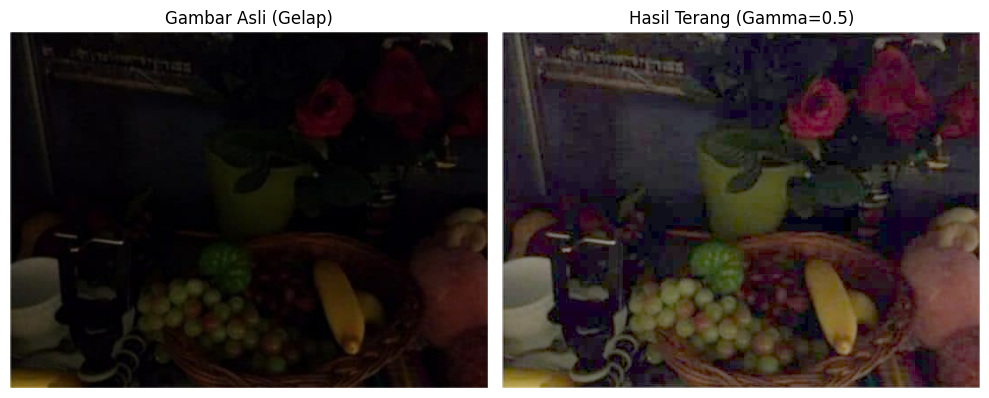

In [24]:
def konversi_gelap_ke_terang(image_path, gamma=0.5, c=1.0):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    r = img.astype(np.float32) / 255.0

    s = c * (r ** gamma)

    s = np.clip(s, 0.0, 1.0)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(r)
    axes[0].set_title('Gambar Asli (Gelap)')
    axes[0].axis('off')

    axes[1].imshow(s)
    axes[1].set_title(f'Hasil Terang (Gamma={gamma})')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

konversi_gelap_ke_terang('dark_image.jpg')

## 2. Penajaman Citra (Dari biasa/soft menjadi lebih tajam/sharp)
Menggunakan High-Pass Filter (Kernel Penajaman/Laplacian). Proses ini mendeteksi perubahan intensitas warna yang ekstrem (tepi objek) menggunakan matriks konvolusi (misal matriks dengan nilai tengah 5 dan sisi -1). Garis tepi ini kemudian diperkuat sehingga gambar yang kabur menjadi lebih tegas dan tajam.

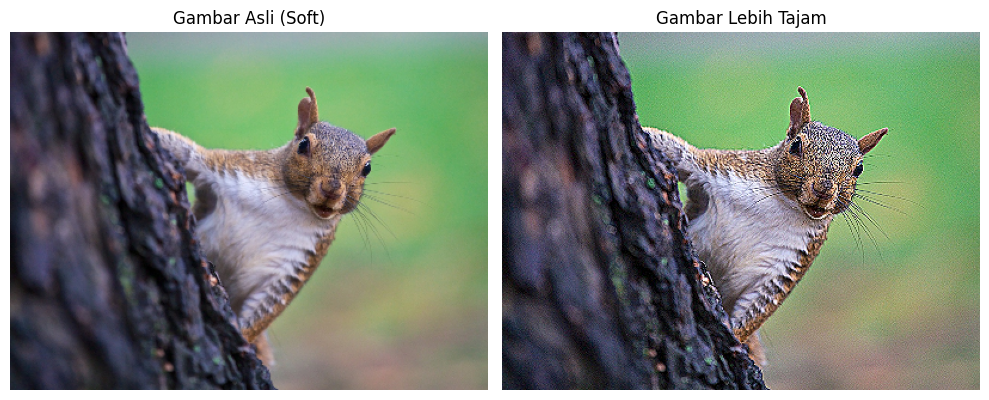

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def konvolusi(channel, kernel):
    h, w = channel.shape
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2

    padded = np.pad(channel, ((pad_h, pad_h), (pad_w, pad_w)), mode='edge')
    output = np.zeros((h, w), dtype=np.float32)

    for i in range(kh):
        for j in range(kw):
            output += padded[i:i+h, j:j+w] * kernel[i, j]

    return output

def penajaman_citra(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img.shape[:2]
    if max(h, w) > 400:
        scale = 400 / max(h, w)
        img = cv2.resize(img, (int(w * scale), int(h * scale)))

    img_float = img.astype(np.float32) / 255.0

    kernel_sharpen = np.array([
        [ 0, -1,  0],
        [-1,  5, -1],
        [ 0, -1,  0]
    ], dtype=np.float32)

    hasil = np.zeros_like(img_float)

    for c in range(3):
        hasil[:, :, c] = konvolusi(img_float[:, :, c], kernel_sharpen)

    hasil = np.clip(hasil, 0, 1)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_float)
    axes[0].set_title('Gambar Asli (Soft)')
    axes[0].axis('off')

    axes[1].imshow(hasil)
    axes[1].set_title('Gambar Lebih Tajam')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

penajaman_citra('soft_image.jpg')

## 3. Peningkatan Kontras (Low Contrast ke High Contrast)
Menggunakan Contrast Stretching. Proses ini mencari nilai piksel paling gelap dan paling terang pada gambar pudar, kemudian "meregangkan" (distribusi linier) nilai-nilai tersebut agar memenuhi rentang penuh spektrum warna (0 hingga 255). Hasilnya, gambar memiliki rentang dinamis yang lebih baik dan tidak lagi terlihat tertutup "kabut" abu-abu.

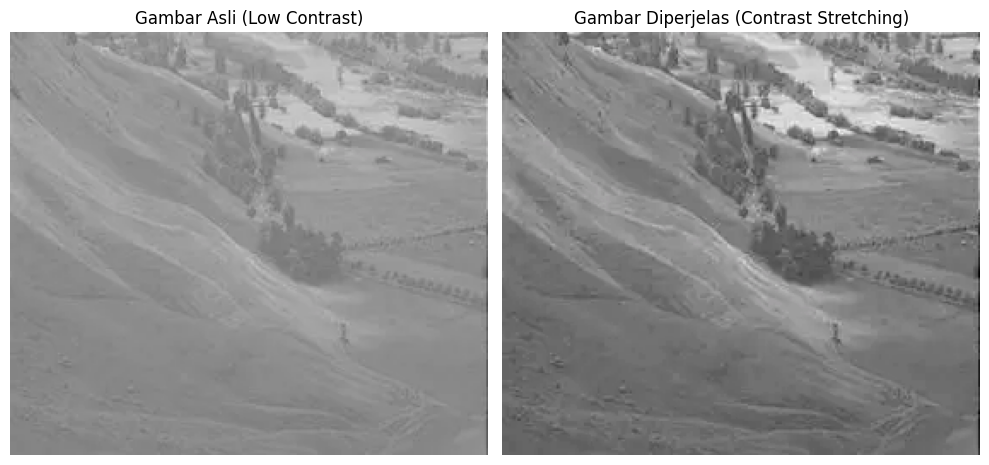

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def peningkatan_kontras(image_path):
    if not os.path.exists(image_path):
        print(f"File '{image_path}' tidak ditemukan.")
        return

    img = cv2.imread(image_path)
    if img is None:
        print(f"File '{image_path}' tidak dapat dibaca.")
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_float = img.astype(np.float32)

    # Mencari nilai intensitas piksel paling gelap (Min) dan paling terang (Max) di gambar asli
    min_val = np.min(img_float)
    max_val = np.max(img_float)

    # Target rentang piksel baru (a = 0, b = 255)
    a = 0.0
    b = 255.0

    # Implementasi rumus Contrast Stretching
    if max_val > min_val:
        hasil = (img_float - min_val) * ((b - a) / (max_val - min_val)) + a
    else:
        hasil = img_float

    hasil = np.clip(hasil, 0, 255).astype(np.uint8)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(img)
    axes[0].set_title('Gambar Asli (Low Contrast)')
    axes[0].axis('off')

    axes[1].imshow(hasil)
    axes[1].set_title('Gambar Diperjelas (Contrast Stretching)')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# Cara penggunaan
peningkatan_kontras('low_contrast.jpg')